# Time Series Fundamentals

## Overview

A time series is a sequence of observations indexed by time. Before modelling, it is essential to understand the structure of the series: its trend, seasonality, and noise components, and whether it is stationary.

**Core concepts:**

| Concept | Meaning |
|---|---|
| Trend | Long-run directional movement |
| Seasonality | Regular periodic pattern (fixed period) |
| Stationarity | Mean and variance constant over time |
| Autocorrelation | Correlation of a series with its own past values |
| ACF | Autocorrelation function: correlation at each lag |
| PACF | Partial ACF: correlation after removing shorter lags |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

rng = np.random.default_rng(42)
dates = pd.date_range("2015-01-01", periods=120, freq="MS")  # 10 years monthly
# Nitrate concentration: trend + seasonal + noise
trend     = np.linspace(2.5, 4.0, 120)
seasonal  = 0.8 * np.sin(2*np.pi*np.arange(120)/12)  # annual cycle
noise     = rng.normal(0, 0.3, 120)
nitrate   = trend + seasonal + noise
ts = pd.Series(nitrate, index=dates, name="nitrate_mg_L")
print(ts.describe().round(3))
print(f"\nDate range: {ts.index[0].date()} to {ts.index[-1].date()}")

count    120.000
mean       3.232
std        0.723
min        1.558
25%        2.668
50%        3.209
75%        3.787
max        4.770
Name: nitrate_mg_L, dtype: float64

Date range: 2015-01-01 to 2024-12-01


---
## Visualisation and Decomposition

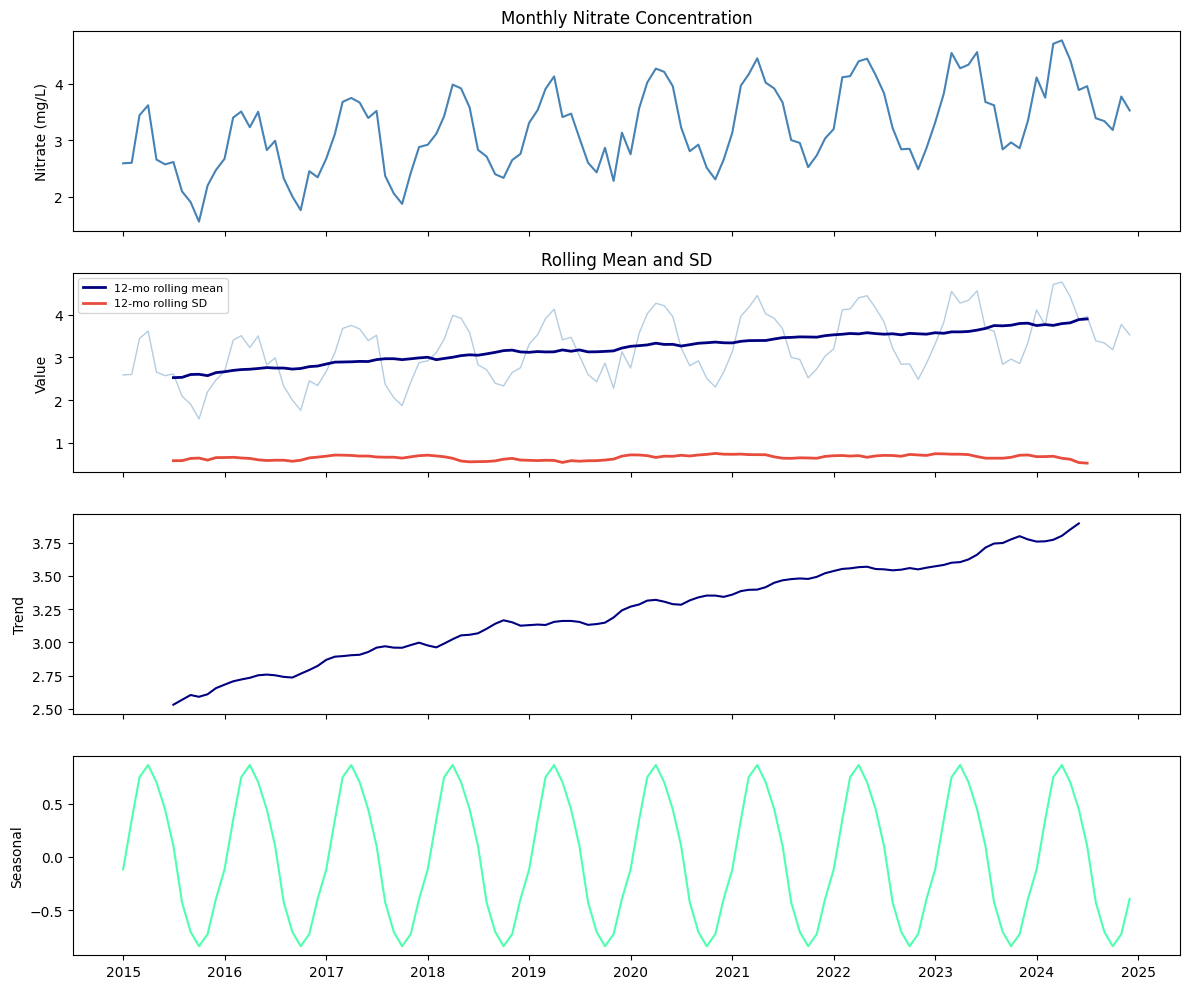

In [2]:
fig, axes = plt.subplots(4,1,figsize=(12,10), sharex=True)
axes[0].plot(ts, color="steelblue", lw=1.5)
axes[0].set_ylabel("Nitrate (mg/L)")
axes[0].set_title("Monthly Nitrate Concentration")
# Rolling statistics
roll_mean = ts.rolling(12, center=True).mean()
roll_std  = ts.rolling(12, center=True).std()
axes[1].plot(ts,        color="steelblue", alpha=0.4, lw=1)
axes[1].plot(roll_mean, color="navy",      lw=2, label="12-mo rolling mean")
axes[1].plot(roll_std,  color="#e74c3c",   lw=2, label="12-mo rolling SD")
axes[1].set_ylabel("Value"); axes[1].legend(fontsize=8)
axes[1].set_title("Rolling Mean and SD")
# Classical decomposition
decomp = seasonal_decompose(ts, model="additive", period=12)
axes[2].plot(decomp.trend, color="navy", lw=1.5)
axes[2].set_ylabel("Trend")
axes[3].plot(decomp.seasonal, color="#4fffb0", lw=1.5)
axes[3].set_ylabel("Seasonal")
plt.tight_layout(); plt.show()

---
## Stationarity Tests

In [3]:
# Augmented Dickey-Fuller: H0 = unit root (non-stationary)
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts, autolag="AIC")
print(f"ADF test: stat={adf_stat:.3f}, p={adf_p:.4f}")
print(f"  Critical values: {adf_crit}")
print(f"  Reject H0 (non-stationary)? {adf_p < 0.05}")
# KPSS: H0 = stationary (complement to ADF)
kpss_stat, kpss_p, _, kpss_crit = kpss(ts, regression="ct", nlags="auto")
print(f"\nKPSS test: stat={kpss_stat:.3f}, p={kpss_p:.4f}")
print(f"  Reject H0 (stationary)? {kpss_p < 0.05}")
print("\nInterpretation: run both tests together")
print("  ADF rejects + KPSS does not reject -> stationary")
print("  ADF does not reject + KPSS rejects -> non-stationary (differencing needed)")

ADF test: stat=-0.635, p=0.8629
  Critical values: {'1%': np.float64(-3.492995948509562), '5%': np.float64(-2.888954648057252), '10%': np.float64(-2.58139291903223)}
  Reject H0 (non-stationary)? False

KPSS test: stat=0.014, p=0.1000
  Reject H0 (stationary)? False

Interpretation: run both tests together
  ADF rejects + KPSS does not reject -> stationary
  ADF does not reject + KPSS rejects -> non-stationary (differencing needed)


C:\Users\saman\AppData\Local\Temp\ipykernel_23024\3901082444.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(ts, regression="ct", nlags="auto")


---
## ACF and PACF

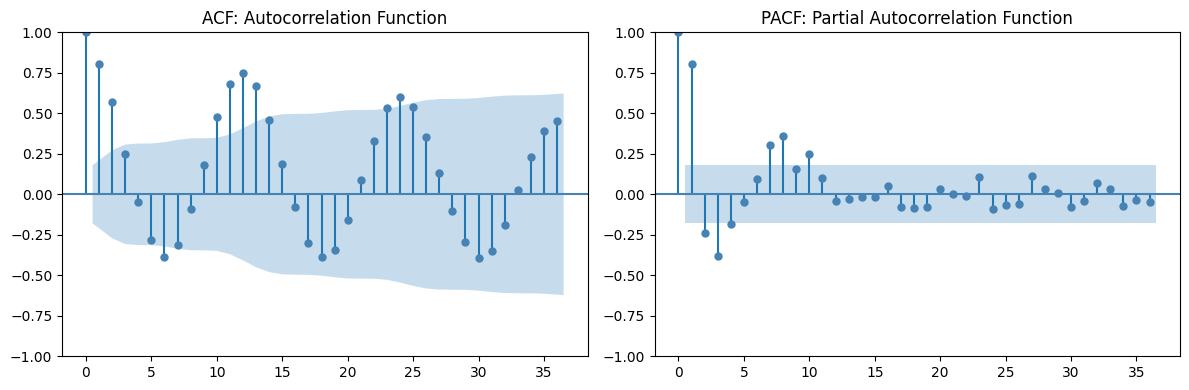

ACF pattern guide:
  Slow decay -> non-stationary (needs differencing)
  Sharp cutoff at lag q -> MA(q) component
  Seasonal spikes at lag 12 -> seasonal component
PACF pattern guide:
  Sharp cutoff at lag p -> AR(p) component


In [4]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
plot_acf(ts,  lags=36, ax=axes[0], color="steelblue")
plot_pacf(ts, lags=36, ax=axes[1], color="steelblue", method="ywm")
axes[0].set_title("ACF: Autocorrelation Function")
axes[1].set_title("PACF: Partial Autocorrelation Function")
plt.tight_layout(); plt.show()
print("ACF pattern guide:")
print("  Slow decay -> non-stationary (needs differencing)")
print("  Sharp cutoff at lag q -> MA(q) component")
print("  Seasonal spikes at lag 12 -> seasonal component")
print("PACF pattern guide:")
print("  Sharp cutoff at lag p -> AR(p) component")

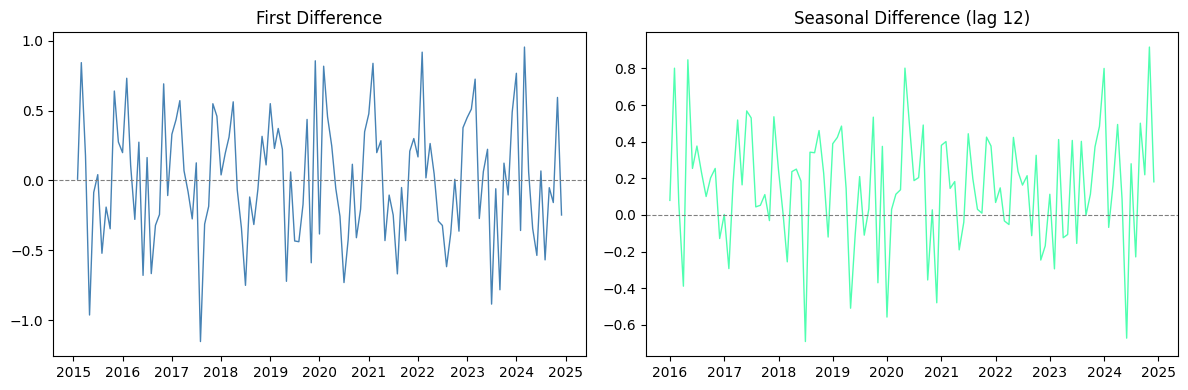

ADF on first difference: p=0.0000


In [5]:
# Differencing to achieve stationarity
ts_diff = ts.diff().dropna()
ts_sdiff = ts.diff(12).dropna()  # seasonal differencing
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(ts_diff, color="steelblue", lw=1)
axes[0].axhline(0, color="grey", lw=0.8, linestyle="--")
axes[0].set_title("First Difference")
axes[1].plot(ts_sdiff, color="#4fffb0", lw=1)
axes[1].axhline(0, color="grey", lw=0.8, linestyle="--")
axes[1].set_title("Seasonal Difference (lag 12)")
plt.tight_layout(); plt.show()
adf_d = adfuller(ts_diff, autolag="AIC")
print(f"ADF on first difference: p={adf_d[1]:.4f}")

---

## Common Pitfalls

**1. Skipping stationarity checks before modelling**  
Most time series models (ARIMA, regression on lagged values) assume stationarity. A non-stationary series will produce spurious correlations and unreliable forecasts. Always run ADF + KPSS and difference if needed.

**2. Using only the ADF test for stationarity**  
ADF and KPSS have opposite null hypotheses and complementary power. A series can "pass" ADF while KPSS simultaneously rejects stationarity. Run both and reconcile the results.

**3. Over-differencing**  
Differencing once is usually sufficient to remove a unit root. Differencing more than needed introduces unnecessary MA structure and increases forecast uncertainty. Check ADF after each differencing step.

**4. Ignoring seasonality before fitting ARIMA**  
A seasonal series will produce misleading ACF/PACF patterns and poor forecasts from a non-seasonal ARIMA. Always check the seasonal ACF (spikes at multiples of the season period) and apply seasonal differencing or use SARIMA.

**5. Reading rolling mean as a forecast**  
A rolling mean describes past behaviour and smooths noise — it is not a forecast. Treating a trailing rolling mean as a prediction conflates descriptive smoothing with forward-looking forecasting.

---
*python_methods_library - Samantha McGarrigle*